# 00 · Интерфейс EPDE шаг за шагом

EPDE ищет дифференциальное уравнение, которому подчиняются данные. Из «кирпичей»
(токенов: переменная, её производные, координаты, sin/cos, ...) собираются
члены-кандидаты, эволюционный многокритериальный поиск составляет из них уравнения,
а результат -- **фронт Парето**: уравнения, по-разному балансирующие точность и
устойчивость/простоту.

В этом ноутбуке интерфейс ветки `domain_refactor` разобран вручную на самой простой
задаче бенчмарка (вынужденный осциллятор), а в конце тот же запуск сделан одним
вызовом вспомогательного пакета `epde_bench`, которым пользуются остальные ноутбуки.

| шаг | вызов | что делает |
|---|---|---|
| 1 | `EpdeSearch(config=...)` | все настройки, сгруппированные по смыслу |
| 2 | `createDomain(grids)` | область данных и граница, которая не учитывается |
| 3 | `createTrajectory({'u': data}, domain)` | подключает данные; здесь считаются производные |
| 4 | семейства токенов | из чего можно строить уравнения |
| 5 | `fit(data=[trajectory])` | эволюционный поиск |
| 6 | `equations()`, `pareto_front` | чтение результата |

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
%matplotlib inline
print('EPDE imported; PIC notebook environment ready')

EPDE imported; PIC notebook environment ready


## Данные

$u'' + \sin(2t)\,u' + 4u = 1.5\,t$ на $t \in [0, 16)$, 320 точек. В обозначениях
EPDE ось времени -- `x0`, поэтому $u'$ -- это `du/dx0`, а $u''$ -- `d^2u/dx0^2`.

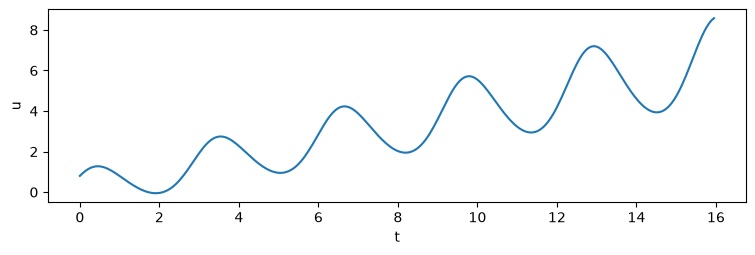

(320,)


In [2]:
t = np.arange(320) * 0.05
u = np.load(PIC / 'data' / 'ode' / 'ode_data.npy')
plt.figure(figsize=(9, 2.5)); plt.plot(t, u); plt.xlabel('t'); plt.ylabel('u'); plt.show()
print(u.shape)

## Шаг 1 · `EpdeSearch` с конфигом

У каждой настройки есть значение по умолчанию в `epde/interface/search_config.py`,
настройки сгруппированы: `domain`, `preprocessing`, `search_space`, `objectives`,
`solver`, `evolution`, `runtime`. Конфиг (словарь, JSON или YAML) переопределяет
умолчания, а именованные аргументы -- конфиг: `EpdeSearch(config=cfg, training_epochs=10)`.

In [3]:
config = {
    'domain':        {'boundary_width': 32},                   # drop 32 points at each end
    'preprocessing': {'default_preprocessor_type': 'FD',       # finite differences
                      'max_deriv_order': [2]},                  # u', u''
    'search_space':  {'data_fun_pow': 3,                        # u, u^2, u^3
                      'deriv_fun_pow': 2,                       # u', (u')^2
                      'equation_terms_max_number': 10,
                      'equation_factors_max_number': {'factors_num': [1, 2], 'probas': [0.65, 0.35]}},
    'evolution':     {'population_size': 16, 'training_epochs': 5},
    'runtime':       {'verbose_params': {'show_iter_idx': False}, 'memory_for_cache': 2},
}
from epde import EpdeSearch
search = EpdeSearch(config=config)
print(search.config.evolution)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x000002C884487AA0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x000002C884487AA0>
EvolutionConfig(population_size=16, training_epochs=5, neighbors_number=3, PBI_penalty=5.0, subregion_mating_limitation=0.9, solution_params={}, director_params={'variation_params': {}, 'mutation_params': {}, 'sorter_params': {}, 'pareto_combiner_params': {}, 'pareto_updater_params': {}}, operators={'MOEADDSelection': {'delta': 0.9, 'parents_fraction': 0.2}, 'PopulationUpdater': {'PBI_penalty': 5.0}, 'SortingBasedNeighborSelector': {'number_of_neighbors': 3}, 'ParetoLevelUpdater': {'mutation_attempt_limit': 3, 'offspring_attempt_limit': 3}, 'InitialParetoLevelSorting': {'uniqueness_attempt_limit': 100}, 'SolverFreeFitness': {'penalty_coeff': 0.2}, 'SolverBasedFitness': {'penalty_coeff': 0.2, 'pinn_loss_mult': 0.0, 'error_metric': 'rmse', 'deepxde_config': {'net': [64, 64, 64, 

## Шаг 2 · домен

`createDomain` принимает по массиву на ось (для ОДУ -- только `t`, для УЧП --
`np.meshgrid(..., indexing='ij')`). `boundary_width` точек у каждого края не
участвуют в подгонке: там производные хуже всего.

In [4]:
domain_id, domain = search.createDomain([t], ID=0)
domain

Set domain <epde.structure.domain.Domain object at 0x000002C8845443E0> with inner shape of [256]


## Шаг 3 · траектория

Данные подключаются к домену словарём `{имя переменной: массив}`. Препроцессор из
шага 1 считает здесь производные (несколько переменных -> система уравнений).

In [5]:
traj_id, trajectory = search.createTrajectory({'u': u}, domain, cache_id=0)

## Шаг 4 · токены

Переменная и её производные в пуле всегда. Всё остальное добавляется семействами
токенов:

* `GridTokens` -- сами координаты (`x{power: 1, dim: 0}` = $t$), нужны для
  вынуждающего члена $1.5t$;
* sin/cos с частотой 2, нужны для $\sin(2t)\,u'$.

**О частоте.** Скрипты в `data/` используют
`TrigonometricTokens(freq=(2 - 1e-8, 2 + 1e-8))`. В `domain_refactor` частоты,
различающиеся больше чем на 5 % ширины интервала, считаются разными токенами, и одна
функция превращается в 20 численно одинаковых токенов, из которых поиск собирает
точные тождества (это показано в ноутбуке 01). `epde_bench.tokens.fixed_trigonometric`
фиксирует частоту в одной точке; печатная форма токена та же.

In [6]:
from epde import GridTokens
from epde_bench.tokens import fixed_trigonometric
grid_tokens = GridTokens(['x'], dimensionality=0, max_power=2)
trig_tokens = fixed_trigonometric(freq=2.0, dimensionality=0)

## Шаг 5 · поиск

Ручной fit включается переменной окружения `EPDE_NOTEBOOK_MANUAL_SEARCH=1`. По умолчанию
ниже показан результат стандартного запуска через проверяемый кэш; повторение обоих
поисков в каждом исполнении не требуется.

In [7]:
# Opt in to repeat the manual teaching search. Default uses the scored cache below.
RUN_MANUAL_SEARCH = os.environ.get('EPDE_NOTEBOOK_MANUAL_SEARCH') == '1'
if RUN_MANUAL_SEARCH:
    t0 = time.time()
    search.fit(data=[trajectory], additional_tokens=[grid_tokens, trig_tokens])
    print(f'{time.time() - t0:.1f} s')

## Шаг 6 · результат

`equations(only_print=True)` печатает первый уровень Парето; с `only_print=False`
возвращает объекты решений (`text_form`, `obj_fun` -- значения целевых функций:
невязка, затем вторая цель, по умолчанию нестабильность).

In [8]:
if RUN_MANUAL_SEARCH:
    search.equations(only_print=True, num=1)

In [9]:
from epde_bench.runner import pareto_front
from epde_bench.nbcache import cached_run
if RUN_MANUAL_SEARCH:
    front, objectives = pareto_front(search)
else:
    rec = cached_run('ode')
    front, objectives = rec.get('front', []), rec.get('objectives', [])
for eqs, obj in zip(front, objectives):
    print(np.round(obj, 4), eqs[0])

[0.0125 0.0001] -3.984485683554886 * u{power: 1.0} + 1.496973458999215 * x{power: 1.0, dim: 0.0} + -0.9885206385764294 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}


## Правильно ли найдено?

Бенчмарк сравнивает **структуры** (наборы членов), а не коэффициенты: истинный
закон здесь `u'' = -4 u - sin(2t) u' + 1.5 t`.

In [10]:
problem = datasets.load('ode')
print(problem.truth[0])
print(metrics.score_run(front, objectives, problem.truth_systems))

-4.0 * u{power: 1.0} + -1.0 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 1.5 * x{power: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'best_index': 0, 'coef_error': 0.005791878178457512}


## То же через `epde_bench`

`datasets.load` возвращает данные, сетки и известную истину для любого набора из
`data/`; `load_config` сливает `configs/_base.yaml`, `configs/<имя>.yaml` и вариант
метода; `discover` выполняет шаги 1-5. Из командной строки:
`python projects/pic/bench.py run ode` (или `python projects/pic/scripts/ode.py`).

In [11]:
cfg = load_config('ode')
search_cfg = resolve_for_problem(cfg, problem)     # fills 'auto' values for this data set
# discover(problem, search_cfg) performs the same native steps.
rec = cached_run('ode')
print(rec['status'], rec.get('fit_seconds'), rec.get('selected'))

ok 40.20373180000024 ['-3.984485683554886 * u{power: 1.0} + 1.496973458999215 * x{power: 1.0, dim: 0.0} + -0.9885206385764294 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}']


## С шумом

Шум 5 % (от std `u`). Сначала **проверка сигнала**: наименьшие квадраты на истинных
членах с производными конечными разностями. Она показывает, сколько закона ещё
видно: член с маленькой «потерей R² без него» не найдёт никакой метод.

In [12]:
p, report = check('ode', noise_levels=[0, 5])
print_check(p, report)

ode: Forced oscillator with time-dependent damping
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -4.0 * u{power: 1.0} + -1.0 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 1.5 * x{power: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + sin(2t) u' + 4u = 1.5t on t in [0, 16), dt = 0.05.

=== noise 0 % ===
R^2 of the true structure: 0.999831   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  u{'power': 1.0}                                                    -4      -3.9845            9.119e-01
  du/dx0{'power': 1.0} * sin{'power': 1.0, 'dim': 0.0, 'freq         -1     -0.98892            5.823e-02
  x{'power': 1.0, 'dim': 0.0}                                       1.5       1.4974            5.044e-01

=== noise 5 % ===
R^2 of the true structure: 0.060609   (d^2u/dx0^2{power: 1.0})
  term            

In [13]:
from epde_bench.nbcache import cached_run
rec = cached_run('ode', variant='default', noise=5.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 37 s (from cache)
[0] <- compromise pick
     0.3776719262905246 * du/dx0{power: 1.0} * x{power: 1.0, dim: 0.0} + -0.026752185511043605 * u{power: 3.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.015931012500262246 * u{power: 3.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[1]
     2.296267887408089 * u{power: 1.0} * d^2u/dx0^2{power: 1.0} + 24.55562608132476 * u{power: 2.0} + -20.573826506859827 * u{power: 1.0} * x{power: 1.0, dim: 0.0} + 4.178285440518317 * x{power: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0} * x{power: 1.0, dim: 0.0}
{'front_size': 2, 'selected_index': 0, 'success_front': False, 'success_selected': False, 'hamming_min': 8, 'hamming_selected': 8, 'coef_error': None}


Дальше: `01_configuration` (все настройки и на что они влияют), затем классы задач
(`02`-`06`) и бенчмарк (`07`).